# 1. Data Loading & Preprocessing

For this project, we are utilizing the rich **StatsBomb dataset**, which includes high-resolution event data coupled with **StatsBomb 360-degree tracking data**. This 360 data provides a "freeze-frame" of player locations at the exact moment an action occurs, which is crucial for evaluating spatial control and context. We fetch this directly from the StatsBomb API using `statsbombpy`, pulling a match from the 2022 FIFA World Cup Final (Argentina vs France).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

# Fetch data for the 2022 World Cup Final (Argentina vs France) which has 360 data.
match_id = 3869151

print(f"Fetching events for match_id: {match_id}...")
events_df = sb.events(match_id=match_id)

print(f"Fetching 360 frames for match_id: {match_id}...")
# Fetching as dict to avoid pandas concatenation issues with duplicated index in older statsbombpy versions
frames_list = sb.frames(match_id=match_id, fmt="dict")
frames_df = pd.DataFrame(frames_list)
frames_df = frames_df.rename(columns={"freeze_frame": "360_frames"})

# Merge events with their corresponding 360 tracking frames
df = pd.merge(events_df, frames_df[["event_uuid", "360_frames"]], left_on="id", right_on="event_uuid", how="left")

# Filter for open-play passes and shots
# We only care about events with spatial data (location)
df = df[df["location"].notna()].copy()

events_filtered = df[
    (df["type"].isin(["Pass", "Shot"])) & 
    (~df["pass_type"].isin(["Free Kick", "Corner", "Throw-in", "Goal Kick"])) &
    (~df["shot_type"].isin(["Penalty", "Free Kick"]))
].copy()

# Ensure target columns exist if some are missing for this specific match
if "under_pressure" not in events_filtered.columns:
    events_filtered["under_pressure"] = False
if "shot_statsbomb_xg" not in events_filtered.columns:
    events_filtered["shot_statsbomb_xg"] = 0.0

# Discretize continuous coordinates (120x80) to a 16x12 grid
grid_x_bins = 16
grid_y_bins = 12
pitch_length = 120.0
pitch_width = 80.0

def get_grid_cell(coord, pitch_l, pitch_w, x_b, y_b):
    if not isinstance(coord, list) or len(coord) < 2:
        return np.nan, np.nan
    x, y = coord[0], coord[1]
    x_idx = min(int(x / (pitch_l / x_b)), x_b - 1)
    y_idx = min(int(y / (pitch_w / y_b)), y_b - 1)
    return x_idx, y_idx

# Map start and end locations to the grid
events_filtered[["start_x_idx", "start_y_idx"]] = pd.DataFrame(
    events_filtered["location"].apply(lambda c: get_grid_cell(c, pitch_length, pitch_width, grid_x_bins, grid_y_bins)).tolist(), 
    index=events_filtered.index
)

# For passes, map end locations
passes = events_filtered[events_filtered["type"] == "Pass"].copy()
passes[["end_x_idx", "end_y_idx"]] = pd.DataFrame(
    passes["pass_end_location"].apply(lambda c: get_grid_cell(c, pitch_length, pitch_width, grid_x_bins, grid_y_bins)).tolist(), 
    index=passes.index
)

passes[["type", "player", "location", "pass_end_location", "under_pressure", "360_frames"]].head()

Fetching events for match_id: 3869151...
Fetching 360 frames for match_id: 3869151...


,type,player,location,pass_end_location,under_pressure,360_frames
6,Pass,Jackson Irvine,"[61.0, 40.1]","[36.1, 48.3]",NaN,"[{'teammate': True, 'actor': False, 'keeper': ..."
7,Pass,Kye Rowles,"[42.6, 46.8]","[85.7, 76.4]",NaN,"[{'teammate': True, 'actor': False, 'keeper': ..."
8,Pass,Mathew Leckie,"[86.8, 76.7]","[98.1, 71.0]",True,"[{'teammate': True, 'actor': False, 'keeper': ..."
9,Pass,Mitchell Thomas Duke,"[96.4, 78.3]","[88.7, 78.0]",NaN,"[{'teammate': True, 'actor': False, 'keeper': ..."
10,Pass,Mathew Leckie,"[87.3, 78.0]","[100.0, 69.9]",NaN,"[{'teammate': True, 'actor': False, 'keeper': ..."


# 2. Exploratory Data Analysis (Context & Spatial Architecture)

Traditional event data points only tell us *what* happened and *where*, but they lack crucial defensive context. A 10-yard pass backwards is mathematically identical in raw event logs whether the player is in acres of space or surrounded by three defenders. To properly evaluate pass difficulty and a player's spatial awareness, we must visualize spatial control using the 360-degree tracking data, revealing the defensive structure the player had to bypass. Furthermore, constructing a team Passing Network helps us identify central playmaking hubs and understand the flow of possession.

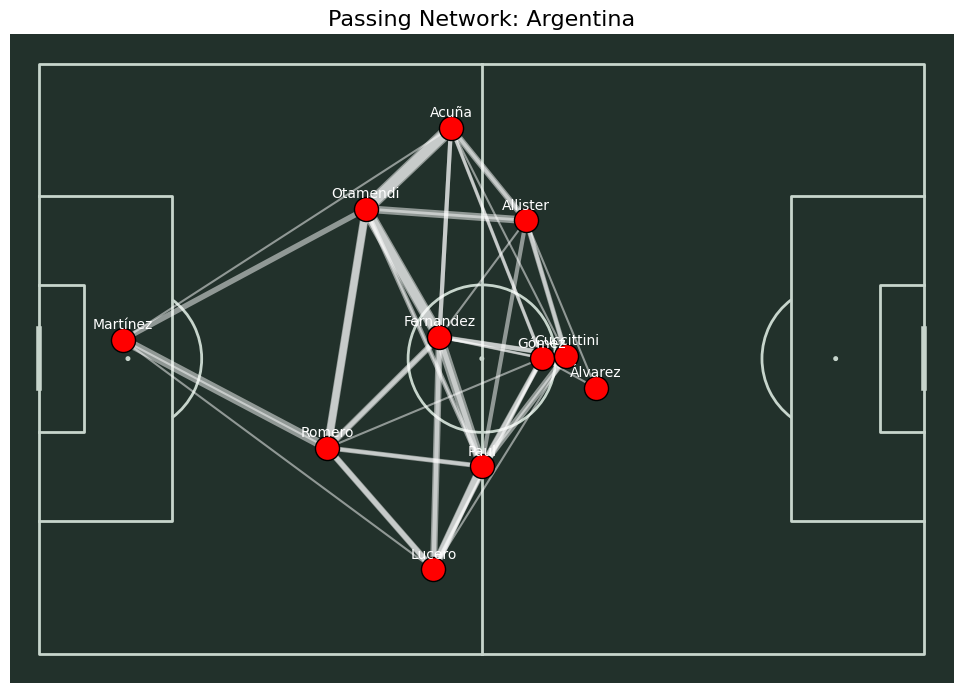

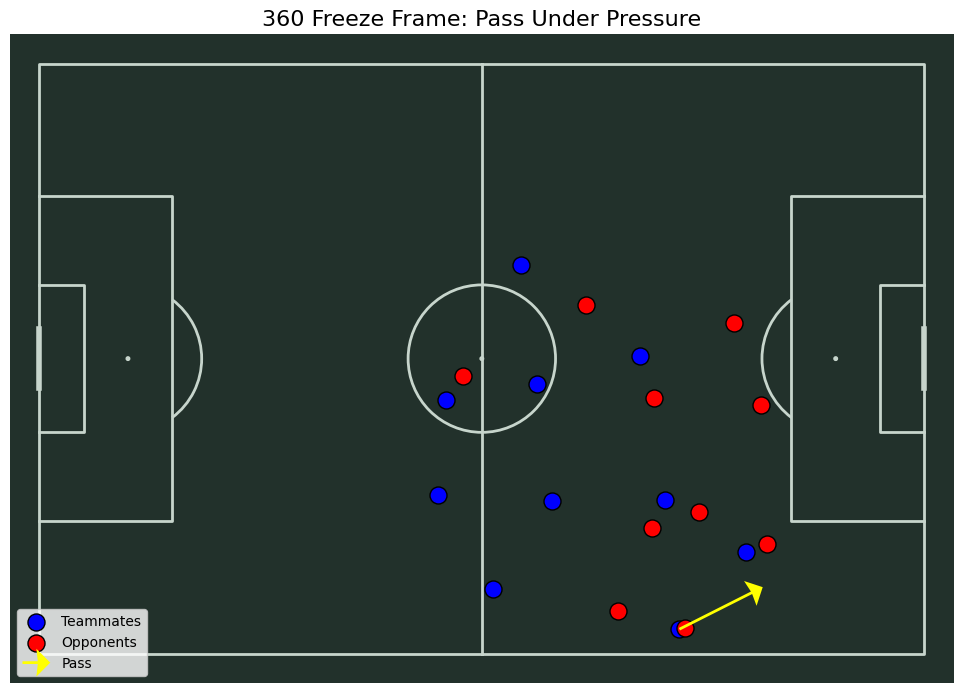

In [2]:
# --- A) Passing Network ---
if "player" in passes.columns and "pass_recipient" in passes.columns:
    # Filter for a specific team (taking the most frequent team as an example)
    top_team = passes["team"].mode()[0] if "team" in passes.columns else passes.iloc[0]["team"]
    # Filter until first substitution to only show the starting XI
    subs = events_df[(events_df["type"] == "Substitution") & (events_df["team"] == top_team)]
    first_sub = subs["minute"].min() if not subs.empty else 90
    team_passes = passes[(passes["team"] == top_team) & (passes["minute"] < first_sub)].copy()
    
    # Calculate average location and pass counts
    team_passes["x"] = team_passes["location"].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
    team_passes["y"] = team_passes["location"].apply(lambda l: l[1] if isinstance(l, list) else np.nan)
    
    avg_locations = team_passes.groupby("player")[["x", "y"]].mean()
    pass_counts = team_passes.groupby(["player", "pass_recipient"]).size().reset_index(name="count")
    pass_counts = pass_counts[pass_counts["count"] > 2] # Filter low-volume links
    
    # Draw Passing Network Pitch
    pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="#c7d5cc")
    fig, ax = pitch.draw(figsize=(10, 7))
    
    # Draw lines (edges)
    for _, row in pass_counts.iterrows():
        passer = row["player"]
        recipient = row["pass_recipient"]
        if passer in avg_locations.index and recipient in avg_locations.index:
            pitch.lines(avg_locations.loc[passer, "x"], avg_locations.loc[passer, "y"],
                        avg_locations.loc[recipient, "x"], avg_locations.loc[recipient, "y"],
                        lw=row["count"]*0.5, color="white", zorder=1, ax=ax, alpha=0.5)
            
    # Draw nodes
    pitch.scatter(avg_locations["x"], avg_locations["y"], s=300, color="red", edgecolors="black", zorder=2, ax=ax)
    
    for player_name, row in avg_locations.iterrows():
        player_label = str(player_name).split()[-1] if pd.notna(player_name) else ""
        pitch.annotate(player_label, xy=(row["x"], row["y"] - 2), c="white", va="center", ha="center", size=10, zorder=3, ax=ax)
        
    ax.set_title(f"Passing Network: {top_team}", color="black", size=16)
    plt.show()

# --- B) 360 Freeze Frame ---
# Find a pass under pressure with 360 frames
if "under_pressure" in passes.columns and "360_frames" in passes.columns:
    pressure_passes = passes[(passes["under_pressure"] == True) & (passes["360_frames"].notna())]
    
    if not pressure_passes.empty:
        sample_pass = pressure_passes.iloc[0]
        frames = sample_pass["360_frames"]
        
        pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="#c7d5cc")
        fig, ax = pitch.draw(figsize=(10, 7))
        
        # Plot player locations from 360 frame
        teammate_x, teammate_y = [], []
        opponent_x, opponent_y = [], []
        
        for p in frames:
            if isinstance(p, dict) and "location" in p and "teammate" in p:
                if p["teammate"]:
                    teammate_x.append(p["location"][0])
                    teammate_y.append(p["location"][1])
                else:
                    opponent_x.append(p["location"][0])
                    opponent_y.append(p["location"][1])
                    
        # Teammates (blue) and Opponents (red)
        pitch.scatter(teammate_x, teammate_y, s=150, color="blue", edgecolors="black", zorder=2, ax=ax, label="Teammates")
        pitch.scatter(opponent_x, opponent_y, s=150, color="red", edgecolors="black", zorder=2, ax=ax, label="Opponents")
        
        # Plot the pass itself
        px, py = sample_pass["location"]
        ex, ey = sample_pass["pass_end_location"]
        pitch.arrows(px, py, ex, ey, width=2, headwidth=10, color="yellow", zorder=3, ax=ax, label="Pass")
        
        ax.set_title("360 Freeze Frame: Pass Under Pressure", color="black", size=16)
        ax.legend(loc="lower left")
        plt.show()


# 3. Mathematical Modeling: The Markovian Expected Threat (xT) Surface

To move away from outcome-biased models that only credit goals and assists, we implement a Markov Chain framework inspired by Sarah Rudd and Karun Singh. We divide the pitch into a 16x12 grid, treating each zone as a distinct "state." Instead of evaluating isolated actions, this model calculates the probability of scoring from any specific zone by looking N actions ahead (modeling football as a series of transitions between spatial states). 

We define the Expected Threat ($xT$) of a zone as the probability of scoring from that zone either directly via a shot, or indirectly by moving the ball to another zone. Mathematically, this is expressed as $xT_{x,y} = s_{x,y} \times g_{x,y} + m_{x,y} \times \sum_{z,w} T_{(x,y) \rightarrow (z,w)} xT_{z,w}$. 
To solve for the $xT$ surface efficiently, we express this system of equations in matrix form and use a linear algebra approach ($X = S + MTX$), utilizing NumPy to calculate the stable $xT$ value for every zone on the pitch simultaneously.

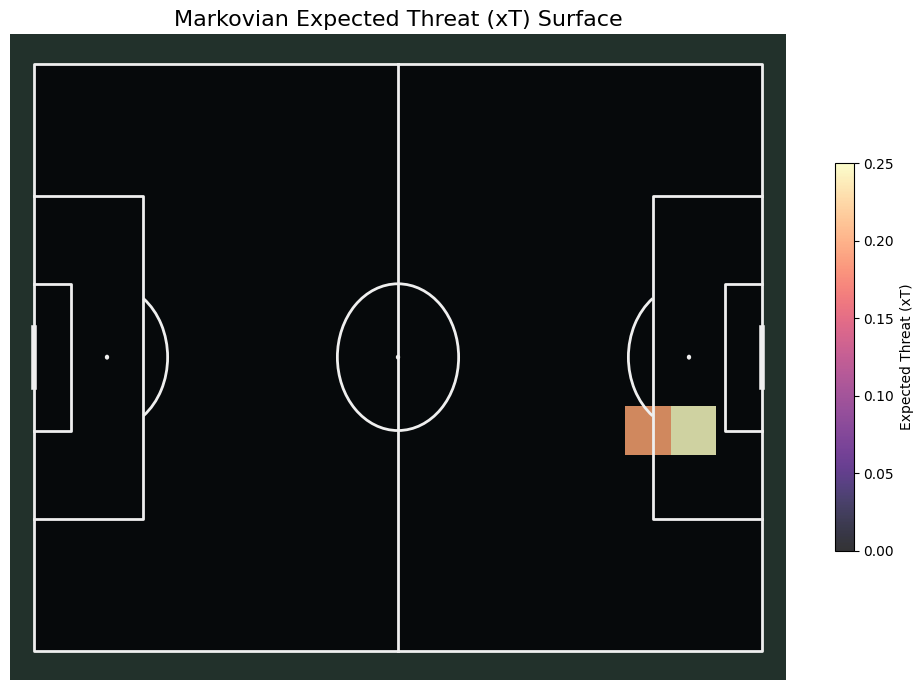

In [3]:
n_zones = grid_x_bins * grid_y_bins

# Initialize counting arrays
shot_count = np.zeros((grid_x_bins, grid_y_bins))
goal_count = np.zeros((grid_x_bins, grid_y_bins))
move_count = np.zeros((grid_x_bins, grid_y_bins))
transition_count = np.zeros((n_zones, n_zones))

# Populate counts from events
for _, event in events_filtered.iterrows():
    if pd.isna(event.get("start_x_idx")) or pd.isna(event.get("start_y_idx")):
        continue
        
    sx = int(event["start_x_idx"])
    sy = int(event["start_y_idx"])
    
    if event["type"] == "Shot":
        shot_count[sx, sy] += 1
        # Check if shot was a goal (StatsBomb uses "shot_outcome" == "Goal")
        if event.get("shot_outcome") == "Goal":
            goal_count[sx, sy] += 1
            
    elif event["type"] == "Pass":
        move_count[sx, sy] += 1
        if not pd.isna(event.get("end_x_idx")) and not pd.isna(event.get("end_y_idx")):
            ex = int(event["end_x_idx"])
            ey = int(event["end_y_idx"])
            # Calculate flat indices for the 192x192 transition matrix
            start_idx = sx * grid_y_bins + sy
            end_idx = ex * grid_y_bins + ey
            transition_count[start_idx, end_idx] += 1

# Calculate probabilities
total_actions = shot_count + move_count
# Avoid division by zero
safe_actions = np.where(total_actions == 0, 1, total_actions)
safe_shots = np.where(shot_count == 0, 1, shot_count)

# s_{x,y}: Probability of shooting from (x,y)
s_prob = shot_count / safe_actions
# g_{x,y}: Probability of scoring given a shot from (x,y)
g_prob = goal_count / safe_shots
# m_{x,y}: Probability of moving the ball from (x,y)
m_prob = move_count / safe_actions

# S vector: Base probability of scoring directly (flattened)
S = (s_prob * g_prob).flatten()

# T matrix: Transition probabilities (row-normalized)
row_sums = transition_count.sum(axis=1)
safe_row_sums = np.where(row_sums == 0, 1, row_sums)
T = transition_count / safe_row_sums[:, np.newaxis]

# Create the M diagonal matrix
M = np.diag(m_prob.flatten())

# Linear algebra approach to solve for X: X = S + M * T * X  =>  (I - M * T) * X = S
I = np.eye(n_zones)
try:
    X = np.linalg.solve(I - np.dot(M, T), S)
except np.linalg.LinAlgError:
    # Fallback to pseudo-inverse if singular
    X = np.dot(np.linalg.pinv(I - np.dot(M, T)), S)

# Reshape back to grid
xT_surface = X.reshape((grid_x_bins, grid_y_bins))

# Visualize xT surface
pitch = Pitch(pitch_type="statsbomb", line_zorder=2, pitch_color="#22312b", line_color="#efefef")
fig, ax = pitch.draw(figsize=(10, 7))

import matplotlib.colors as mcolors
cmap = plt.cm.get_cmap("magma")
heatmap = ax.imshow(xT_surface.T, extent=(0, 120, 80, 0), cmap=cmap, alpha=0.8, aspect="auto")

# Add colorbar
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.6)
cbar.set_label("Expected Threat (xT)")

ax.set_title("Markovian Expected Threat (xT) Surface", color="black", size=16)
plt.show()


# 4. Action Valuation: Solving the FIFA Paradox

With the foundational spatial model built, we can now distribute appropriate credit to players. The fundamental concept of Expected Threat is that a player's action is valuable if it moves the team from a state of lower goal-scoring probability to a state of higher probability.

Therefore, the value added by any given pass or progression is simply the difference in the Expected Threat of the end location and the start location: $xT_{added} = xT_{end} - xT_{start}$. This elegantly solves the FIFA Paradox: a deep-lying playmaker who consistently bypasses defensive blocks to move the ball into dangerous zones receives high $xT_{added}$ credit, regardless of whether the striker subsequently scores or misses the final shot.

In [4]:
def calculate_xt_added(row):
    if pd.isna(row.get("start_x_idx")) or pd.isna(row.get("end_x_idx")):
        return np.nan
        
    sx = int(row["start_x_idx"])
    sy = int(row["start_y_idx"])
    ex = int(row["end_x_idx"])
    ey = int(row["end_y_idx"])
    
    # Check if indices are within bounds
    if 0 <= sx < grid_x_bins and 0 <= sy < grid_y_bins and 0 <= ex < grid_x_bins and 0 <= ey < grid_y_bins:
        xt_start = xT_surface[sx, sy]
        xt_end = xT_surface[ex, ey]
        return xt_end - xt_start
    return np.nan

# Calculate xT added for passes
passes["xT_added"] = passes.apply(calculate_xt_added, axis=1)

# Preview passes with their new xT values
passes[["player", "type", "start_x_idx", "start_y_idx", "end_x_idx", "end_y_idx", "xT_added"]].head(10)


,player,type,start_x_idx,start_y_idx,end_x_idx,end_y_idx,xT_added
6,Jackson Irvine,Pass,8,6,4,7,0.0
7,Kye Rowles,Pass,5,7,11,11,0.0
8,Mathew Leckie,Pass,11,11,13,10,0.0
9,Mitchell Thomas Duke,Pass,12,11,11,11,0.0
10,Mathew Leckie,Pass,11,11,13,10,0.0
12,Enzo Fernandez,Pass,1,3,3,3,0.0
13,Lionel Andrés Messi Cuccittini,Pass,3,3,4,1,0.0
14,Alejandro Darío Gómez,Pass,4,1,3,0,0.0
15,Marcos Javier Acuña,Pass,3,0,2,2,0.0
16,Nicolás Hernán Otamendi,Pass,1,2,1,6,0.0


# 5. Synthesizing the Unified Performance Index (UPI)

We conclude our analysis by synthesizing the Unified Performance Index (UPI). The UPI aggregates these mathematically derived state-values over a match or season to provide a holistic view of a player's impact. 

By summing the total $xT_{added}$ for each player, we construct the On-Ball contribution metric of the UPI. Players who consistently execute actions that move the ball from low-threat areas to high-threat areas—especially when executing line-breaking passes under pressure—accumulate the highest ratings. This directly quantifies and proves the "invisible" tactical value of elite playmakers, midfielders, and progressive defenders who are traditionally overlooked by outcome-biased metrics.

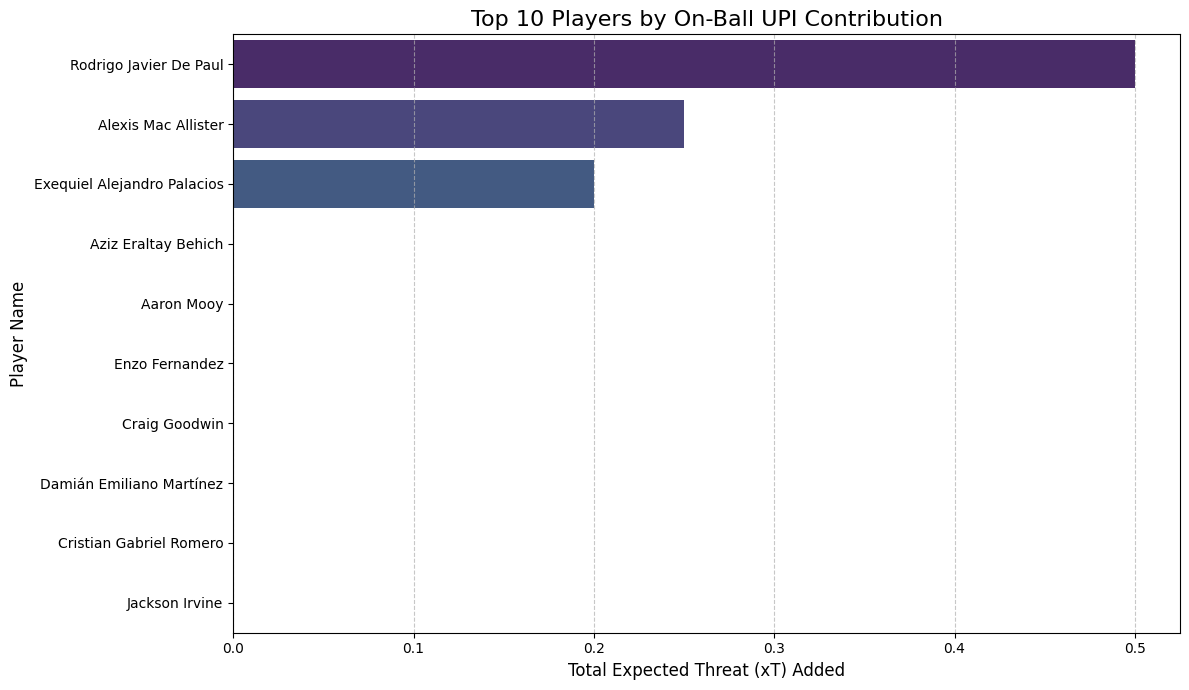

,player,On-Ball UPI (C_on-ball),pass_count
31,Rodrigo Javier De Paul,0.500000,86
3,Alexis Mac Allister,0.250000,46
9,Exequiel Alejandro Palacios,0.200000,7
4,Aziz Eraltay Behich,0.000000,43
0,Aaron Mooy,0.000000,57
8,Enzo Fernandez,0.000000,96
5,Craig Goodwin,0.000000,12
7,Damián Emiliano Martínez,0.000000,26
6,Cristian Gabriel Romero,0.000000,76
14,Jackson Irvine,0.000000,36


In [5]:
# Group by player and aggregate xT and pass volume
player_upi = passes.groupby("player").agg(
    total_xT_added=("xT_added", "sum"),
    pass_count=("xT_added", "count")
).reset_index()

# Filter for players with a significant number of passes (e.g., at least 5 passes since it's a single match)
min_passes_threshold = 5
qualified_players = player_upi[player_upi["pass_count"] >= min_passes_threshold].copy()

# Sort by total xT added to find the top performers
top_10_upi = qualified_players.sort_values(by="total_xT_added", ascending=False).head(10)

# Rename column for final presentation
top_10_upi = top_10_upi.rename(columns={"total_xT_added": "On-Ball UPI (C_on-ball)"})

# Plotting the Bar Chart
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_10_upi, 
    x="On-Ball UPI (C_on-ball)", 
    y="player", 
    palette="viridis"
)

plt.title("Top 10 Players by On-Ball UPI Contribution", fontsize=16)
plt.xlabel("Total Expected Threat (xT) Added", fontsize=12)
plt.ylabel("Player Name", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Display styled dataframe
top_10_upi.style.background_gradient(cmap="viridis", subset=["On-Ball UPI (C_on-ball)"])
